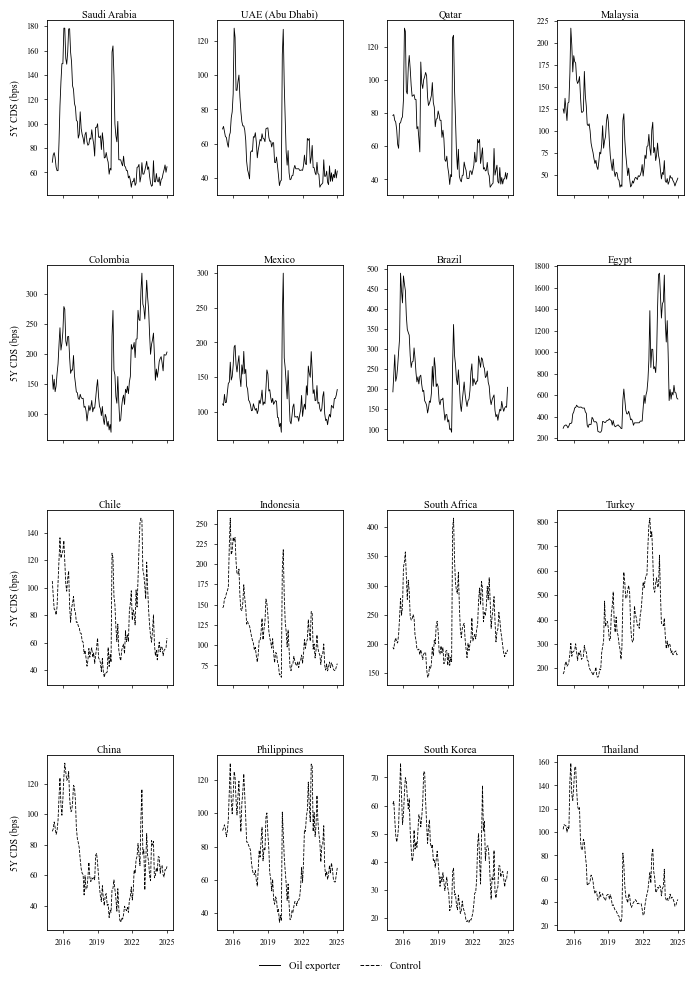

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

panel = pd.read_csv('../output/final/complete_results_weekly_15_dampening.csv',
                    parse_dates=['date'])

monthly = (panel
           .set_index('date')
           .groupby('country')['cds_spread']
           .resample('ME').last()
           .reset_index())

ORDER = ['Saudi Arabia', 'UAE (Abu Dhabi)', 'Qatar', 'Malaysia',
         'Colombia', 'Mexico', 'Brazil', 'Egypt',
         'Chile', 'Indonesia', 'South Africa', 'Turkey',
         'China', 'Philippines', 'South Korea', 'Thailand']

EXPORTERS = set(['Saudi Arabia', 'UAE (Abu Dhabi)', 'Qatar', 'Malaysia',
                 'Colombia', 'Mexico', 'Brazil', 'Egypt'])

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.linewidth': 0.6,
    'axes.edgecolor': 'black',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
})

# A4 text width with 2.5cm margins ≈ 6.3in. Aspect ratio 1:1 → 6.3in tall.
fig, axes = plt.subplots(4, 4, figsize=(7.0, 10.0), sharex=True)

# Tight spacing — kill the default whitespace
plt.subplots_adjust(wspace=0.35, hspace=0.40, left=0.08, right=0.99, 
                    top=0.97, bottom=0.06)

for idx, country in enumerate(ORDER):
    row, col = idx // 4, idx % 4
    ax = axes[row, col]
    sub = monthly[monthly['country'] == country]
    
    linestyle = '-' if country in EXPORTERS else '--'
    
    ax.plot(sub['date'], sub['cds_spread'],
            color='black', linewidth=0.6, linestyle=linestyle)
    ax.set_title(country, fontsize=7.5, pad=1.5)
    ax.tick_params(axis='both', labelsize=6)
    ax.grid(False)

# Date axis on bottom row only
for col in range(4):
    ax = axes[3, col]
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center', fontsize=6)

# Y-label on leftmost column
for ax in axes[:, 0]:
    ax.set_ylabel('5Y CDS (bps)', fontsize=7)

# Legend
legend_elements = [
    Line2D([0], [0], color='black', linestyle='-',  linewidth=0.7, label='Oil exporter'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=0.7, label='Control'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           frameon=False, fontsize=7.5, bbox_to_anchor=(0.5, 0.01))

plt.savefig('cds_grid_bw.pdf', bbox_inches='tight', dpi=300, pad_inches=0.05)
plt.show()

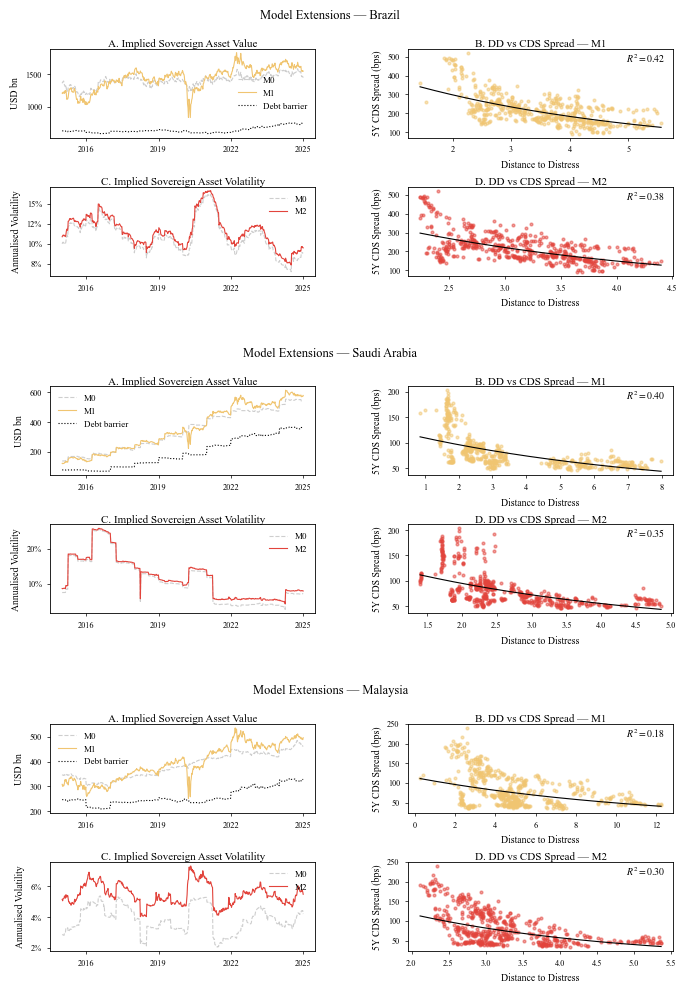

Saved to ../output/final/model_extensions_panel.pdf
Done


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import PercentFormatter  # at the top with the other imports

# Edit this list to pick the 3 countries you want to display
COUNTRIES = ['Brazil', 'Saudi Arabia', 'Malaysia']
OUT_PDF   = '../output/final/model_extensions_panel.pdf'

RED  = '#E2443C'
GOLD = "#f0c571"
GRAY = '#cecece'

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.linewidth': 0.6,
    'axes.edgecolor': 'black',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
})

df = pd.read_csv('../output/final/complete_results_weekly_15_dampening.csv')


def plot_country(country, subfig):
    c = df[df['country'] == country].copy().reset_index(drop=True)
    c['date'] = pd.to_datetime(c['date'])

    gs = GridSpec(2, 2, figure=subfig, hspace=0.55, wspace=0.35)
    ax_a = subfig.add_subplot(gs[0, 0])
    ax_b = subfig.add_subplot(gs[0, 1])
    ax_c = subfig.add_subplot(gs[1, 0])
    ax_d = subfig.add_subplot(gs[1, 1])

    # --- Panel A: Asset Value M0 vs M1 + debt barrier ---
    ax_a.plot(c['date'], c['implied_V_M0'], color=GRAY, linewidth=0.8,
              linestyle='--', label='M0')
    ax_a.plot(c['date'], c['implied_V_M1'], color=GOLD, linewidth=0.8,
              linestyle='-', label='M1')
    ax_a.plot(c['date'], c['B_f'], color='black', linewidth=0.8,
              linestyle=':', label='Debt barrier')
    ax_a.set_title('A. Implied Sovereign Asset Value', fontsize=8, pad=1.5)
    ax_a.set_ylabel('USD bn', fontsize=7)
    ax_a.tick_params(axis='both', labelsize=6)
    ax_a.xaxis.set_major_locator(mdates.YearLocator(3))
    ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax_a.get_xticklabels(), rotation=0, ha='center', fontsize=6)
    ax_a.legend(fontsize=6.5, frameon=False)

    # --- Panel C: Asset Volatility M0 vs M2 ---
    ax_c.plot(c['date'], c['implied_sigma_V_M0'], color=GRAY, linewidth=0.8,
              linestyle='--', label='M0')
    ax_c.plot(c['date'], c['implied_sigma_V_M2'], color=RED, linewidth=0.8,
              linestyle='-', label='M2')
    ax_c.set_title('C. Implied Sovereign Asset Volatility', fontsize=8, pad=1.5)
    ax_c.set_ylabel('Annualised Volatility', fontsize=7)
    ax_c.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax_c.tick_params(axis='both', labelsize=6)
    ax_c.xaxis.set_major_locator(mdates.YearLocator(3))
    ax_c.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax_c.get_xticklabels(), rotation=0, ha='center', fontsize=6)
    ax_c.legend(fontsize=6.5, frameon=False)

    # --- Panel B: DD vs CDS scatter M1 ---
    ax_b.scatter(c['DD_M1'], c['cds_spread'], s=4, alpha=0.5, color=GOLD)

    log_y = np.log(c['cds_spread'].clip(1))
    coef_m1 = np.polyfit(c['DD_M1'], log_y, 1)
    x_range_m1 = np.linspace(c['DD_M1'].min(), c['DD_M1'].max(), 200)
    ax_b.plot(x_range_m1, np.exp(np.polyval(coef_m1, x_range_m1)),
              color='black', linewidth=0.8)

    y_pred_m1 = np.exp(np.polyval(coef_m1, c['DD_M1']))
    r2_m1 = 1 - np.sum((c['cds_spread'] - y_pred_m1)**2) / np.sum((c['cds_spread'] - c['cds_spread'].mean())**2)

    ax_b.text(0.97, 0.97,
        f'$R^2={r2_m1:.2f}$',
        transform=ax_b.transAxes, fontsize=7, va='top', ha='right')
    ax_b.set_title('B. DD vs CDS Spread — M1', fontsize=8, pad=1.5)
    ax_b.set_xlabel('Distance to Distress', fontsize=7)
    ax_b.set_ylabel('5Y CDS Spread (bps)', fontsize=7)
    ax_b.tick_params(axis='both', labelsize=6)

    # --- Panel D: DD vs CDS scatter M2 ---
    ax_d.scatter(c['DD_M2'], c['cds_spread'], s=4, alpha=0.5, color=RED)

    coef_m2 = np.polyfit(c['DD_M2'], log_y, 1)
    x_range_m2 = np.linspace(c['DD_M2'].min(), c['DD_M2'].max(), 200)
    ax_d.plot(x_range_m2, np.exp(np.polyval(coef_m2, x_range_m2)),
              color='black', linewidth=0.8)

    y_pred_m2 = np.exp(np.polyval(coef_m2, c['DD_M2']))
    r2_m2 = 1 - np.sum((c['cds_spread'] - y_pred_m2)**2) / np.sum((c['cds_spread'] - c['cds_spread'].mean())**2)

    ax_d.text(0.97, 0.97,
        f'$R^2={r2_m2:.2f}$',
        transform=ax_d.transAxes, fontsize=7, va='top', ha='right')
    ax_d.set_title('D. DD vs CDS Spread — M2', fontsize=8, pad=1.5)
    ax_d.set_xlabel('Distance to Distress', fontsize=7)
    ax_d.set_ylabel('5Y CDS Spread (bps)', fontsize=7)
    ax_d.tick_params(axis='both', labelsize=6)

    subfig.suptitle(f'Model Extensions — {country}', fontsize=9, fontweight='normal')
    subfig.subplots_adjust(left=0.10, right=0.99, top=0.86, bottom=0.16)


# A4 text width with 2.5cm margins ≈ 6.3in. Same sizing as CDS grid figure.
fig = plt.figure(figsize=(7.0, 10.0))
subfigs = fig.subfigures(3, 1, hspace=0.04)
for sf, country in zip(subfigs, COUNTRIES):
    plot_country(country, sf)

fig.savefig(OUT_PDF, bbox_inches='tight', dpi=300, pad_inches=0.05)
plt.show()
print(f"Saved to {OUT_PDF}")
print("Done")

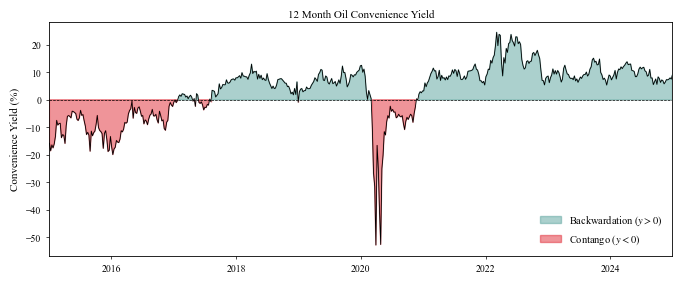

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.linewidth': 0.6,
    'axes.edgecolor': 'black',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
})

RED  = '#e02b35'
GREEN = '#59a39c'

df = pd.read_csv('../output/final/complete_results_weekly_15_dampening.csv',
                 parse_dates=['date'])

cy = df[df['country'] == 'Brazil'][['date', 'convenience_yield']].drop_duplicates().sort_values('date')
cy = cy[cy['date'] >= '2015-01-01']  # add this line
cy['convenience_yield_pct'] = cy['convenience_yield'] * 100

fig, ax = plt.subplots(figsize=(7.0, 3.0))
plt.subplots_adjust(left=0.10, right=0.99, top=0.92, bottom=0.14)

ax.plot(cy['date'], cy['convenience_yield_pct'], color='black', linewidth=0.6)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

ax.fill_between(cy['date'], cy['convenience_yield_pct'], 0,
                where=cy['convenience_yield_pct'] > 0,
                color=GREEN, alpha=0.5, label='Backwardation ($y > 0$)')
ax.fill_between(cy['date'], cy['convenience_yield_pct'], 0,
                where=cy['convenience_yield_pct'] < 0,
                color=RED, alpha=0.5, label='Contango ($y < 0$)')

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=0, ha='center', fontsize=7)
ax.tick_params(axis='both', labelsize=7)
ax.set_ylabel('Convenience Yield (%)', fontsize=8)
ax.set_xlabel('')
ax.set_xlim(cy['date'].min(), cy['date'].max())
ax.legend(fontsize=7.5, frameon=False, loc='lower right')
ax.set_title('12 Month Oil Convenience Yield',
             fontsize=8, pad=3)
plt.show()

In [10]:
# Convenience yield distribution
y = cy['convenience_yield'].dropna()

print("CONVENIENCE YIELD (y)")
print(f"  Min:    {y.min():.4f}  ({y.min()*100:.1f}%)")
print(f"  Max:    {y.max():.4f}  ({y.max()*100:.1f}%)")
print(f"  Mean:   {y.mean():.4f}  ({y.mean()*100:.1f}%)")
print(f"  Median: {y.median():.4f}  ({y.median()*100:.1f}%)")
print(f"  Std:    {y.std():.4f}  ({y.std()*100:.1f}%)")
print(f"  5th %ile:  {y.quantile(0.05):.4f}  ({y.quantile(0.05)*100:.1f}%)")
print(f"  95th %ile: {y.quantile(0.95):.4f}  ({y.quantile(0.95)*100:.1f}%)")
print(f"  Pct backwardation (y>0): {(y > 0).mean()*100:.1f}%")
print(f"  Pct contango (y<0):      {(y < 0).mean()*100:.1f}%")

# Rolling 52-week annualised volatility of innovations
sig = cy['convenience_yield'].diff().rolling(52).std() * np.sqrt(52)
sig = sig.dropna()

print("\nINNOVATION VOLATILITY (sigma_y, annualised)")
print(f"  Min:    {sig.min():.4f}  ({sig.min()*100:.1f}%)")
print(f"  Max:    {sig.max():.4f}  ({sig.max()*100:.1f}%)")
print(f"  Mean:   {sig.mean():.4f}  ({sig.mean()*100:.1f}%)")
print(f"  Median: {sig.median():.4f}  ({sig.median()*100:.1f}%)")

CONVENIENCE YIELD (y)
  Min:    -0.5275  (-52.7%)
  Max:    0.2449  (24.5%)
  Mean:   0.0327  (3.3%)
  Median: 0.0669  (6.7%)
  Std:    0.1005  (10.1%)
  5th %ile:  -0.1444  (-14.4%)
  95th %ile: 0.1526  (15.3%)
  Pct backwardation (y>0): 69.5%
  Pct contango (y<0):      30.5%

INNOVATION VOLATILITY (sigma_y, annualised)
  Min:    0.0882  (8.8%)
  Max:    0.6114  (61.1%)
  Mean:   0.1917  (19.2%)
  Median: 0.1299  (13.0%)


/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_7130/3991114822.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')


FileNotFoundError: [Errno 2] No such file or directory: '../output/figures/jump_calibration.pdf'

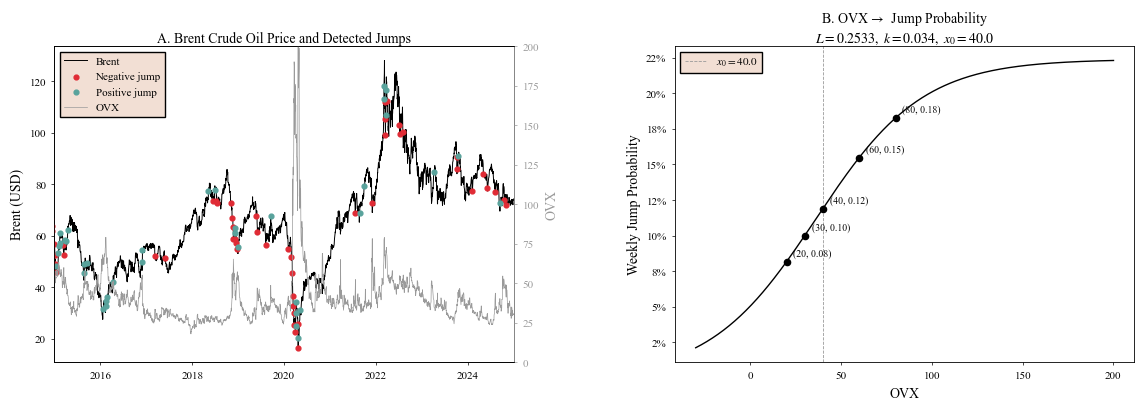

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 10,
    'axes.linewidth': 0.6,
    'axes.edgecolor': 'black',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
})

RED  = '#e02b35'
GOLD = '#f0c571'
GRAY = '#9a9a9a'
GREEN = '#59a39c'
OIL_COL    = 'Brent'
OVX_COL    = 'OVXCLS'
Z_THRESH   = -2.5
VOL_WINDOW = 252

L, k, x0 = 0.2533, 0.034, 40.0

def sigmoid(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

oil_price = pd.read_csv('../data/oil_prices_datastream.csv')
ovx       = pd.read_csv('../data/OVXCLS.csv')
oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')
ovx['date']       = pd.to_datetime(ovx['date'],       errors='coerce')

df = (pd.merge(oil_price[['date', OIL_COL]], ovx[['date', OVX_COL]],
               on='date', how='inner')
        .sort_values('date')
        .reset_index(drop=True))
df.ffill(inplace=True)
df = df[(df['date'] > '2013-01-01') & (df['date'] < '2024-12-31')]

df['log_ret']    = np.log(df[OIL_COL] / df[OIL_COL].shift(1))
df['roll_sigma'] = df['log_ret'].rolling(VOL_WINDOW, min_periods=126).std()
df['z_score']    = df['log_ret'] / df['roll_sigma']
df.dropna(subset=['log_ret', 'roll_sigma', OVX_COL], inplace=True)

df['jump_daily'] = (np.abs(df['z_score']) > np.abs(Z_THRESH)).astype(int)
neg_jump_days    = df[(df['jump_daily'] == 1) & (df['z_score'] < 0)]
pos_jump_days    = df[(df['jump_daily'] == 1) & (df['z_score'] > 0)]

# Restrict Panel A display to 2015 onward
df_panel_a = df[df['date'] >= '2015-01-01']
neg_jump_days = neg_jump_days[neg_jump_days['date'] >= '2014-01-01']
pos_jump_days = pos_jump_days[pos_jump_days['date'] >= '2014-01-01']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 4.0))
plt.subplots_adjust(left=0.07, right=0.97, top=0.92, bottom=0.13, wspace=0.35)

# ── Panel A ───────────────────────────────────────────────
ax1_r = ax1.twinx()
ax1_r.plot(df_panel_a['date'], df_panel_a[OVX_COL], lw=0.5, color=GRAY, zorder=1, label='OVX')
ax1_r.set_ylabel('OVX', fontsize=10, color=GRAY)
ax1_r.tick_params(axis='y', labelsize=8, colors=GRAY)
ax1_r.spines['right'].set_edgecolor(GRAY)
ax1_r.set_ylim(0, 200)

ax1.plot(df_panel_a['date'], df_panel_a[OIL_COL], lw=0.7, color='black', zorder=2, label='Brent')
ax1.scatter(neg_jump_days['date'], neg_jump_days[OIL_COL],
            color=RED,  s=12, zorder=5, label='Negative jump')
ax1.scatter(pos_jump_days['date'], pos_jump_days[OIL_COL],
            color=GREEN, s=12, zorder=5, label='Positive jump')

ax1.set_xlim(pd.Timestamp('2015-01-01'), pd.Timestamp('2024-12-31'))

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax1.get_xticklabels(), rotation=0, ha='center', fontsize=8)
ax1.tick_params(axis='y', labelsize=8)
ax1.set_ylabel('Brent (USD)', fontsize=10)
ax1.set_title('A. Brent Crude Oil Price and Detected Jumps', fontsize=10, pad=3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_r.get_legend_handles_labels()
# Very soft, pale salmon — the gentlest option
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=8, loc='upper left',
           frameon=True, facecolor="#f2dfd4", edgecolor='black',
           framealpha=1.0, fancybox=False)

# ── Panel B: sigmoid with hardcoded parameters ────────────
ovx_range = np.linspace(-30, 200, 300)
lam_weekly = sigmoid(ovx_range, L, k, x0)
jump_prob  = 1 - np.exp(-lam_weekly)

ref_ovx  = [20, 30, 40, 60, 80]
ref_prob = [1 - np.exp(-sigmoid(v, L, k, x0)) for v in ref_ovx]

ax2.plot(ovx_range, jump_prob, color='black', lw=1.0)
ax2.scatter(ref_ovx, ref_prob, color='black', s=20, zorder=5)
for v, p in zip(ref_ovx, ref_prob):
    ax2.annotate(f'({v}, {p:.2f})', (v, p),
                 textcoords='offset points', xytext=(5, 4), fontsize=7)

ax2.axvline(x0, color=GRAY, lw=0.6, linestyle='--', label=f'$x_0={x0}$')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.tick_params(axis='both', labelsize=8)
ax2.set_xlabel('OVX', fontsize=10)
ax2.set_ylabel('Weekly Jump Probability', fontsize=10)
ax2.set_title(
    f'B. OVX$\\,\\to\\,$ Jump Probability\n'
    f'$L={L},\\ k={k},\\ x_0={x0}$',
    fontsize=10, pad=3)
ax2.legend(fontsize=8, loc='upper left',
           frameon=True, facecolor='#f2dfd4', edgecolor='black',
           framealpha=1.0, fancybox=False)
plt.savefig('../output/figures/jump_calibration.pdf',
            bbox_inches='tight', dpi=300, pad_inches=0.05)
plt.savefig('../output/figures/jump_calibration.png',
            bbox_inches='tight', dpi=300, pad_inches=0.05)
plt.show()
print("Done")

FileNotFoundError: [Errno 2] No such file or directory: '../output/figures/copula_density.pdf'

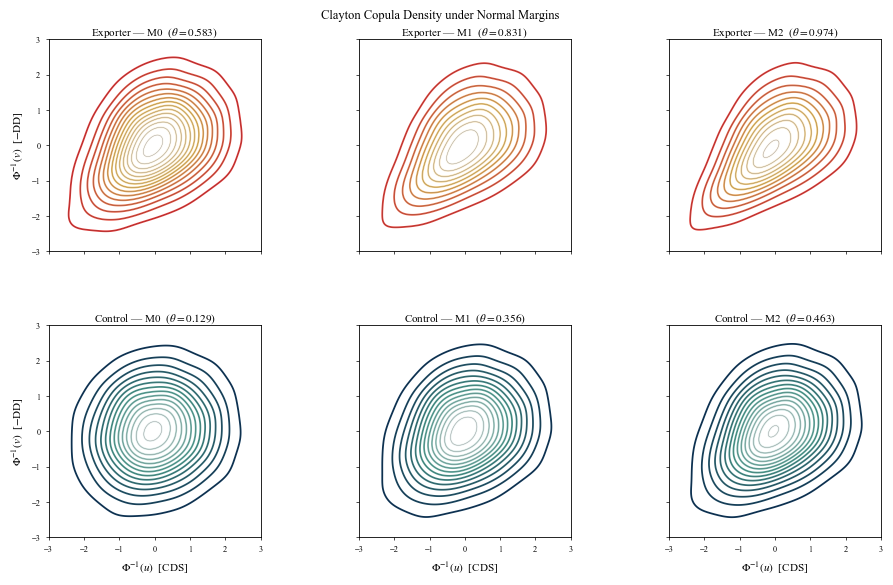

In [143]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from scipy.stats import norm, gaussian_kde
import pyvinecopulib as pv

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.linewidth': 0.6,
    'axes.edgecolor': 'black',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
})

# Thesis color palettes as custom colormaps
cmap_exporter = mcolors.LinearSegmentedColormap.from_list(
    'exporter', ['#e02b35', '#f0c571', '#ffffff']  # red → gold → white
)
cmap_control = mcolors.LinearSegmentedColormap.from_list(
    'control', ['#082a54', '#59a89c', '#ffffff']   # dark blue → teal → white
)

thetas = {
    ('Exporter', 'M0'): 0.583,
    ('Exporter', 'M1'): 0.831,
    ('Exporter', 'M2'): 0.974,
    ('Control',  'M0'): 0.129,
    ('Control',  'M1'): 0.356,
    ('Control',  'M2'): 0.463,
}

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
plt.subplots_adjust(left=0.08, right=0.97, top=0.93, bottom=0.10,
                    wspace=0.15, hspace=0.35)

groups = ['Exporter', 'Control']
models = ['M0', 'M1', 'M2']
cmaps  = {'Exporter': cmap_exporter, 'Control': cmap_control}

for i, group in enumerate(groups):
    for j, model in enumerate(models):
        ax = axes[i, j]
        theta = thetas[(group, model)]

        cop     = pv.Bicop(family=pv.BicopFamily.clayton,
                           parameters=np.array([[theta]]))
        samples = cop.simulate(20000, seeds=[42])
        x = norm.ppf(samples[:, 0])
        y = norm.ppf(samples[:, 1])

        kde  = gaussian_kde(np.vstack([x, y]), bw_method=0.3)
        grid = np.linspace(-3, 3, 200)
        X, Y = np.meshgrid(grid, grid)
        Z    = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        ax.contour(X, Y, Z, levels=15, cmap=cmaps[group], linewidths=1.3)
        ax.contour(X, Y, Z, levels=15, colors='black', linewidths=0.3, alpha=0.4)
        ax.set_title(f'{group} — {model}  ($\\theta = {theta:.3f}$)',
                     fontsize=8, pad=2)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect('equal')
        ax.tick_params(axis='both', labelsize=6)
        if i == 1:
            ax.set_xlabel(r'$\Phi^{-1}(u)$  [CDS]', fontsize=8)
        if j == 0:
            ax.set_ylabel(r'$\Phi^{-1}(v)$  [$-$DD]', fontsize=8)

fig.suptitle('Clayton Copula Density under Normal Margins',
             fontsize=9, fontweight='normal')
plt.savefig('../output/figures/copula_density.pdf',
            bbox_inches='tight', dpi=300, pad_inches=0.05)
plt.savefig('../output/figures/copula_density.png',
            bbox_inches='tight', dpi=300, pad_inches=0.05)
plt.show()
print("Done")